In [2]:
import pandas as pd
import os
import smarts_cerebellum.globals as gl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# DTI metrics
dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'WMPMII_DTI_flip.tsv'), sep = '\t')
dti = dti[(dti.isPatient == 1) & (dti.regionname == 'CST_R')] # just patients in ipsilesional CST

# decenter the mean (for each week)
for metric in dti.metric.unique():
    for week in gl.weeks:
        rows = (dti.metric == metric) & (dti.Week == week)
        dti.loc[rows, 'decentered_mean_week'] = dti.loc[rows, 'mean'] - dti.loc[rows, 'mean'].mean()

/localscratch/tmp/ipykernel_47481/1126270689.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'WMPMII_DTI_flip.tsv'), sep = '\t')


# Axial diffusivity

In [3]:
# week-by-week correlations of AD (lambda_1) (using decentered mean for each week)

ad_dti = dti[dti.metric == 'lambda_1']
ad = ad_dti.pivot(index = ['subj_id'], columns = 'Week', values = 'decentered_mean_week').reset_index(drop = True)
ad_corr = np.diag(ad.corr(method = 'pearson', numeric_only = True).values, k = -1)

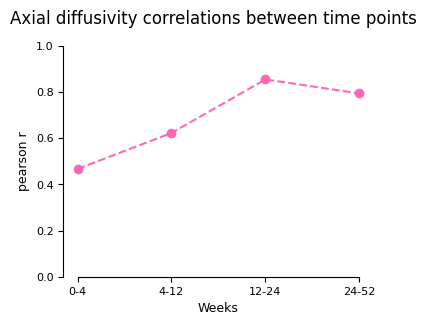

In [4]:
# plot the subdiagonal of ad.corr() to get correlations between adjacent weeks
fig, ax = plt.subplots(figsize = (4,3))
ax.plot(ad_corr, linestyle = '--', marker = 'o', color = 'hotpink')

ax.set_xticks(range(len(ad_corr)))
ax.set_xticklabels(['0-4', '4-12', '12-24', '24-52'])
ax.set_ylim(0, 1)

plt.suptitle("Axial diffusivity correlations between time points", y = 1)
ax.set_xlabel("Weeks")
ax.set_ylabel("pearson r")

sns.despine(trim = True)
plt.show()

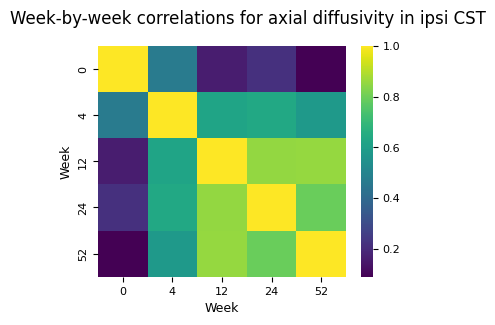

In [5]:
# week-by-week correlations of AD (lambda_1) (using decentered mean for each week)
fig, ax = plt.subplots(figsize = (4,3))
sns.heatmap(ad.corr(), cmap = 'viridis')
fig.suptitle("Week-by-week correlations for axial diffusivity in ipsi CST", y = 1)
plt.show()

# Radial diffusivity

In [6]:
# week-by-week correlations of AD (lambda_1) (using decentered mean for each week)

rd_dti = dti[dti.metric == 'radial_diffusivity']
rd = rd_dti.pivot(index = ['subj_id'], columns = 'Week', values = 'decentered_mean_week').reset_index(drop = True)
rd_corr = np.diag(rd.corr(method = 'pearson', numeric_only = True).values, k = -1)

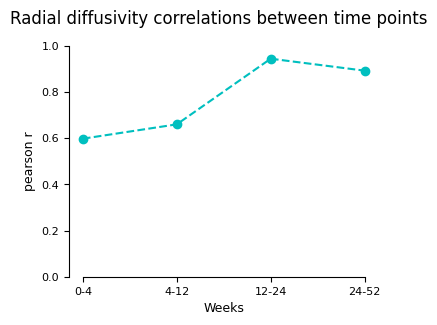

In [7]:
# plot the subdiagonal of ad.corr() to get correlations between adjacent weeks
fig, ax = plt.subplots(figsize = (4,3))
ax.plot(rd_corr, linestyle = '--', marker = 'o', color = 'c')

ax.set_xticks(range(len(rd_corr)))
ax.set_xticklabels(['0-4', '4-12', '12-24', '24-52'])
ax.set_ylim(0, 1)

plt.suptitle("Radial diffusivity correlations between time points", y = 1)
ax.set_xlabel("Weeks")
ax.set_ylabel("pearson r")

sns.despine(trim = True)
plt.show()

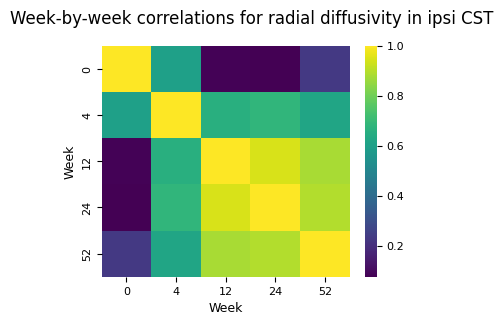

In [8]:
# week-by-week correlations of RD (using decentered mean for each week)
fig, ax = plt.subplots(figsize = (4,3))
sns.heatmap(rd.corr(), cmap = 'viridis')
fig.suptitle("Week-by-week correlations for radial diffusivity in ipsi CST", y = 1)
plt.show()